In [98]:
import numpy as np
import mne
from pathlib import Path

import matplotlib.pyplot as plt

from scipy.signal import resample_poly, find_peaks, welch
from scipy.stats import gaussian_kde

In [99]:
dataset_path = Path("BCI4_2a")
subject_id = 3

In [100]:
def read_subject_epochs(subject_id: int, dataset_path: Path,
                        is_train: bool = True,
                        l_freq: float = 4.0,
                        h_freq: float = 37.0,
                        tmin: float = -0.5,
                        tmax: float = 4.5):
    """
    Загружает EEG одного субъекта BCI IV 2a и возвращает:
    epochs, X, y, label_names
    """
    subject_prefix = f"A0{subject_id}"
    train_eval_label = "T" if is_train else "E"
    subject_training_data_path = dataset_path / (subject_prefix + f"{train_eval_label}.gdf")

    raw = mne.io.read_raw_gdf(subject_training_data_path, preload=True)
    bci_channels = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2',
    'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz'
    ]

    # Создаем соответствие с индексами каналов в данных
    # (если каналы называются иначе)
    if raw.ch_names[0].startswith('EEG'):
        rename_dict = dict()
        for key, value in zip(raw.ch_names[:-3], bci_channels):
            rename_dict[key] = value
        raw.rename_channels(rename_dict)
    raw.filter(l_freq, h_freq, verbose=False)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])

    raw.set_montage('standard_1020')

    events, event_dict = mne.events_from_annotations(raw)

    event_id = {
        "left": event_dict["769"],
        "right": event_dict["770"],
        "foot": event_dict["771"],
        "tongue": event_dict["772"],
    }

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose=False
    )

    X = epochs.get_data()  # (n_epochs, n_channels, n_times)
    y_raw = epochs.events[:, -1]

    label_map = {
        event_dict["769"]: 0,
        event_dict["770"]: 1,
        event_dict["771"]: 2,
        event_dict["772"]: 3,
    }
    inv_label_map = {0: "left", 1: "right", 2: "foot", 3: "tongue"}

    y = np.array([label_map[i] for i in y_raw])

    return epochs, X, y, inv_label_map

In [101]:
epochs, X, y, inv_label_map = read_subject_epochs(subject_id, dataset_path, l_freq=1, h_freq=40)

Extracting GDF parameters from BCI4_2a/A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 660529  =      0.000 ...  2642.116 secs...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


In [102]:
freqs = np.arange(1, 40, 1)  # Частоты от 4 до 30 Гц с шагом 1 Гц
n_cycles = freqs / 2.

In [103]:
epochs_morle = epochs.compute_tfr(
    method='morlet',
    freqs=freqs,
    n_cycles=n_cycles,
    average=False,
    return_itc=False,
    picks='eeg'
)

In [104]:
epochs_left = epochs_morle['left'].data

In [105]:
left_sample_reshaped = epochs_morle['left'].data.transpose(0, 2, 3, 1)
right_sample_reshaped = epochs_morle['right'].data.transpose(0, 2, 3, 1)
left_sample_reshaped.shape

(72, 39, 1251, 22)

In [106]:
adj = mne.channels.find_ch_adjacency(epochs.info, 'eeg')
time_adjacency = mne.stats.combine_adjacency(
    left_sample_reshaped.shape[1], left_sample_reshaped.shape[2], adj[0]
)

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 22


In [107]:
import os
print(os.cpu_count())

8


In [108]:
import scipy.stats
p_unc = 0.05
dfn = 1  # степени свободы числителя (между группами) = количество групп - 1
dfd = (left_sample_reshaped.shape[0] + right_sample_reshaped.shape[0] - 2)  # внутригрупповые степени свободы
f_thresh = scipy.stats.f.ppf(1 - p_unc, dfn, dfd)

In [109]:
#f_thresh=dict(start=0, step=0.2)

In [110]:
F_obs, clusters, cluster_pv, H0 = mne.stats.permutation_cluster_test([left_sample_reshaped, right_sample_reshaped], threshold=f_thresh, n_permutations=1000,
                                   adjacency=time_adjacency, seed = 42, n_jobs = 6, check_disjoint=True)

stat_fun(H1): min=8.933284757910709e-12 max=21.42470370685487
No disjoint adjacency sets found
Running initial clustering …
Found 109 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

In [122]:
set(clusters[10][2])

{np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21)}

In [115]:
cluster_pv[10]

np.float64(0.049)

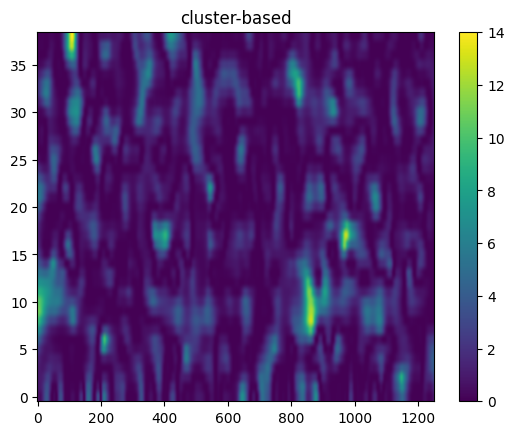

In [114]:
plt.imshow(F_obs[:,:,10], origin='lower', aspect='auto')
plt.colorbar()
plt.title('cluster-based')
plt.show()